Workshop-2


In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score


In [ ]:
#1. Softmax Function
def softmax(z):

    z_stable = z - np.max(z, axis=1, keepdims=True)

    exp_z = np.exp(z_stable)

    probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)

    return probs


In [ ]:
#2. Prediction Function
def predict_softmax(X, W, b):

    z = np.dot(X, W) + b

    probs = softmax(z)

    predicted_classes = np.argmax(probs, axis=1)

    return predicted_classes

In [ ]:
#3. Cross Entropy Loss Function
def loss_softmax(y_pred, y):

    n = y.shape[0]

    loss = -np.sum(y * np.log(y_pred + 1e-15)) / n

    return loss

In [ ]:
#4. Cost Function
def cost_softmax(X, y, W, b):

    n = X.shape[0]

    z = np.dot(X, W) + b

    y_pred = softmax(z)

    total_loss = -np.sum(y * np.log(y_pred + 1e-15))

    return total_loss / n

In [ ]:
#5. Compute Gradient
def compute_gradient_softmax(X, y, W, b):

    n = X.shape[0]

    z = np.dot(X, W) + b

    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n

    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b


In [ ]:
#6. Gradient Descent
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):

    cost_history = []

    for i in range(n_iter):

        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        W = W - alpha * grad_W

        b = b - alpha * grad_b

        cost = cost_softmax(X, y, W, b)

        cost_history.append(cost)

        if show_cost and i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost}")

    return W, b, cost_history

In [ ]:
#7. Plot Sample Images
def plot_sample_images(X, y):

    plt.figure(figsize=(10,4))

    unique_classes = np.unique(y)

    for i, digit in enumerate(unique_classes):

        index = np.where(y == digit)[0][0]

        image = X[index].reshape(28,28)

        plt.subplot(2,5,i+1)

        plt.imshow(image, cmap='gray')

        plt.title(f"Digit: {digit}")

        plt.axis('off')

    plt.tight_layout()

    plt.show()

In [ ]:
#8. Load and Prepare MNIST Dataset
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):

    df = pd.read_csv(csv_file)

    y = df.iloc[:,0].values

    X = df.iloc[:,1:].values

    X = X / 255.0

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test

In [ ]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

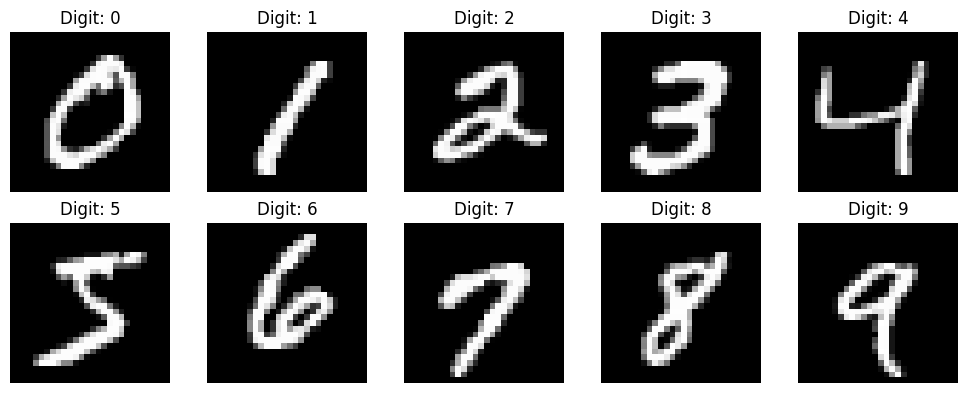

In [ ]:
X_train, X_test, y_train, y_test = load_and_prepare_mnist("mnist_dataset.csv")


In [ ]:
#10. One-Hot Encoding
encoder = OneHotEncoder(sparse_output=False)

y_train = encoder.fit_transform(y_train.reshape(-1,1))

y_test = encoder.transform(y_test.reshape(-1,1))


In [ ]:
#11. Initialize Model Parameters
d = X_train.shape[1]

c = y_train.shape[1]

W = np.random.randn(d, c) * 0.01

b = np.zeros(c)

alpha = 0.1

n_iter = 1000


In [ ]:
#12. Train the Model
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

Iteration 0, Cost: 2.1849999173201975
Iteration 100, Cost: 0.6068104999108568
Iteration 200, Cost: 0.4892812402336588
Iteration 300, Cost: 0.4407398295991519
Iteration 400, Cost: 0.41269600523521643
Iteration 500, Cost: 0.3938500256269411
Iteration 600, Cost: 0.3800419388624988
Iteration 700, Cost: 0.369343656033576
Iteration 800, Cost: 0.3607249956257949
Iteration 900, Cost: 0.3535792366751582


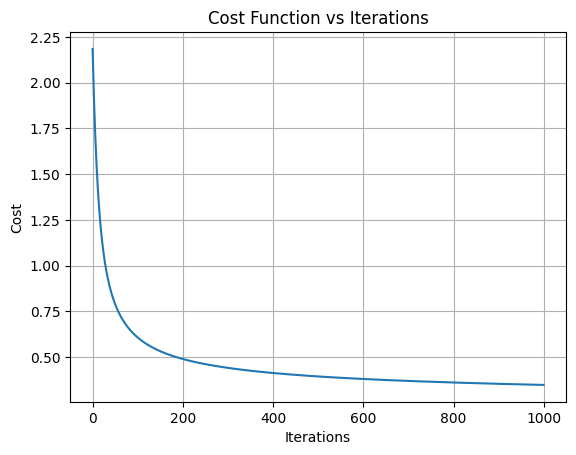

In [ ]:
#13. Plot Cost vs Iterations
plt.plot(cost_history)

plt.title("Cost Function vs Iterations")

plt.xlabel("Iterations")

plt.ylabel("Cost")

plt.grid(True)

plt.show()

In [ ]:
#14. Evaluation Function
def evaluate_classification(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    precision = precision_score(y_true, y_pred, average='weighted')

    recall = recall_score(y_true, y_pred, average='weighted')

    f1 = f1_score(y_true, y_pred, average='weighted')

    return cm, precision, recall, f1

In [ ]:
#15. Model Evaluation
y_pred_test = predict_softmax(X_test, W_opt, b_opt)

y_test_labels = np.argmax(y_test, axis=1)

cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")

print(cm)

print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)


Confusion Matrix:
[[1128    0    5    2    3   10    9    2   13    3]
 [   0 1276    7   10    1    5    1    4   17    1]
 [   1   14 1030   15   19    5   27   24   32    7]
 [   8    5   34 1050    1   54    9    8   29   21]
 [   1    5    7    1 1094    0   10    4    4   50]
 [  22   14   14   42   12  926   14    7   40   13]
 [   7    2   10    1   11   15 1119    2   10    0]
 [   7   26   25    4   16    2    0 1183    7   29]
 [   8   25   14   35    9   31   14    7 1003   14]
 [   8    6   10   18   45    9    0   38   10 1050]]
Precision: 0.9045697291470927
Recall: 0.9049166666666667
F1 Score: 0.9045962989534574


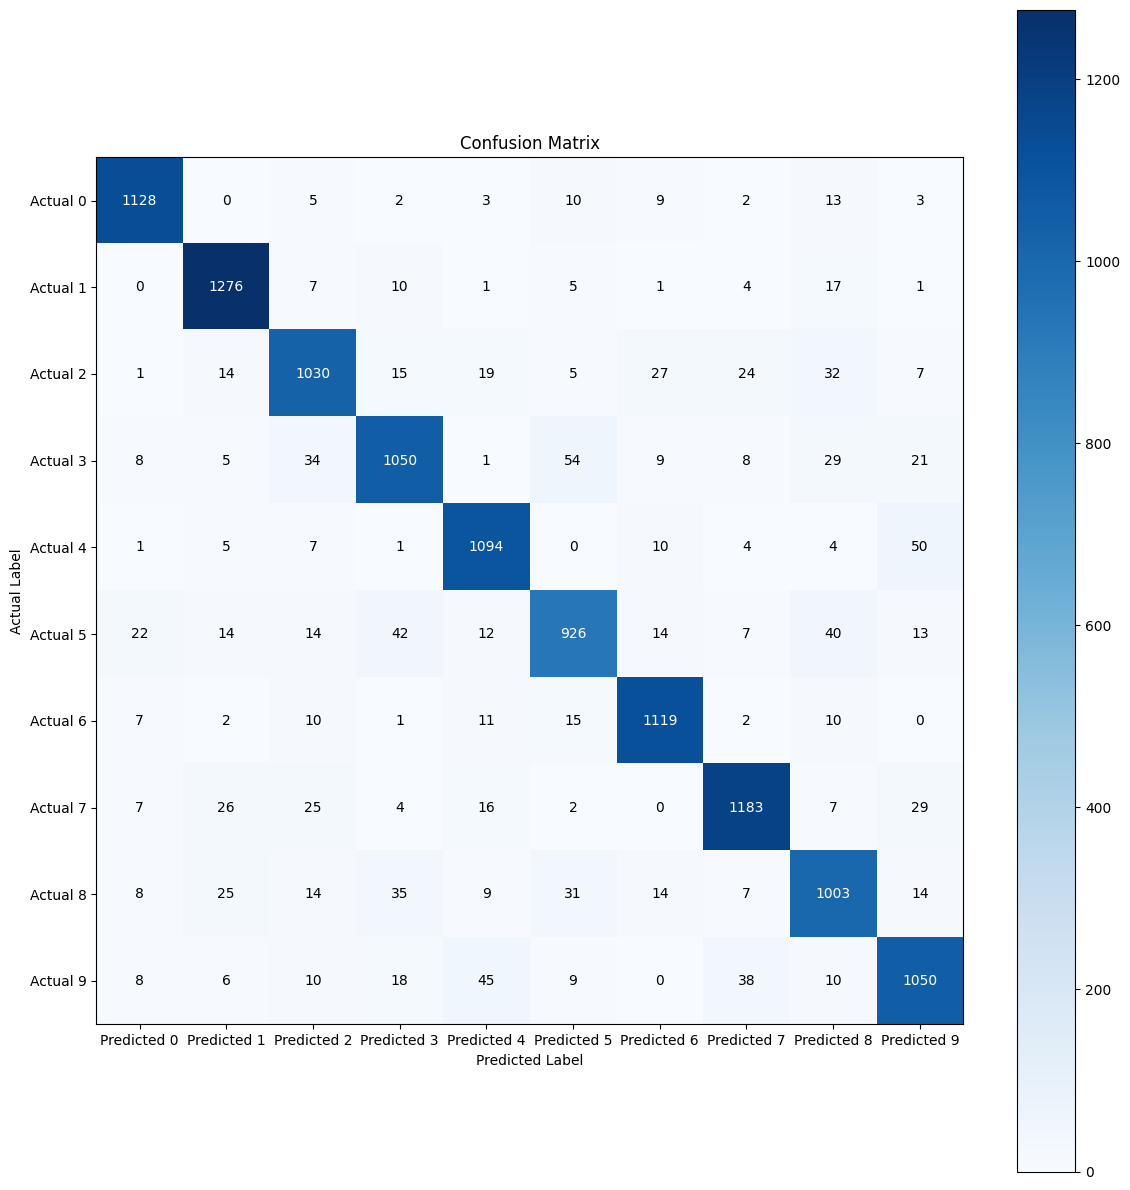

In [ ]:
#16. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(12,12))

cax = ax.imshow(cm, cmap='Blues')

num_classes = cm.shape[0]

ax.set_xticks(range(num_classes))

ax.set_yticks(range(num_classes))

ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])

ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha='center', va='center',
                color='white' if cm[i,j] > np.max(cm)/2 else 'black')

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.colorbar(cax)

plt.tight_layout()

plt.show()